In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/train.csv')
df.head()

,age,gender,primary_diagnosis,num_procedures,days_in_hospital,comorbidity_score,discharge_to,readmitted
0,69,Male,Heart Disease,1,2,1,Home Health Care,0
1,32,Female,COPD,2,13,2,Rehabilitation Facility,0
2,89,Male,Diabetes,1,7,1,Home,0
3,78,Male,COPD,9,2,2,Skilled Nursing Facility,0
4,38,Male,Diabetes,6,4,4,Rehabilitation Facility,0


In [3]:
df.shape

(5000, 8)

In [4]:
df.isnull().sum()

,0
age,0
gender,0
primary_diagnosis,0
num_procedures,0
days_in_hospital,0
comorbidity_score,0
discharge_to,0
readmitted,0


In [5]:
print(min(df['age']),max(df['age']))

18 89


[]

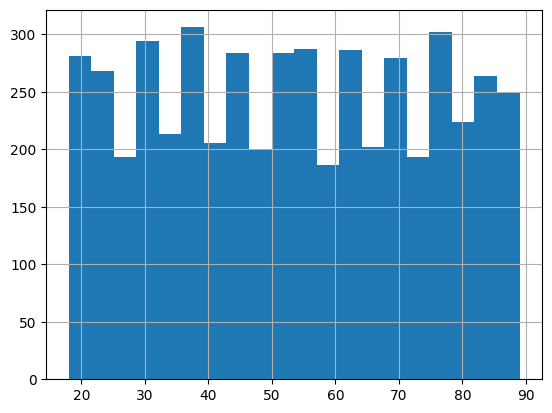

In [6]:
df['age'].hist(bins=20).plot()

<Axes: xlabel='gender'>

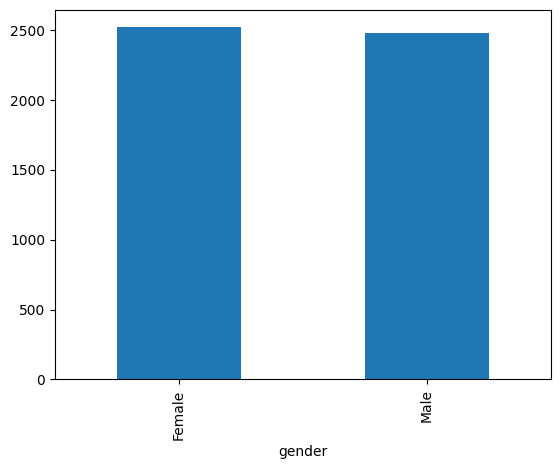

In [7]:
df['gender'].value_counts().plot(kind='bar')

<Axes: xlabel='primary_diagnosis'>

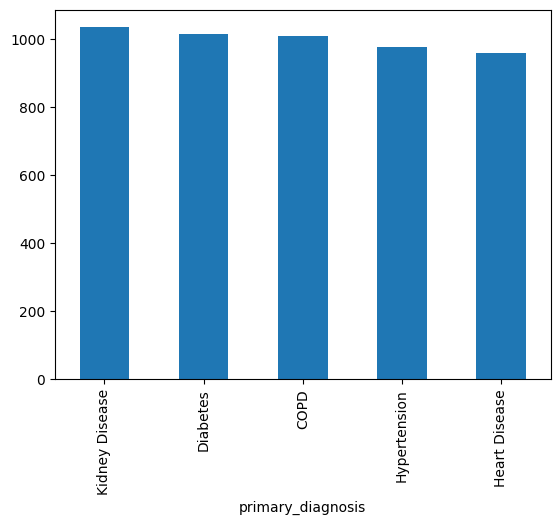

In [8]:
df['primary_diagnosis'].value_counts().plot(kind='bar')

<Axes: xlabel='num_procedures'>

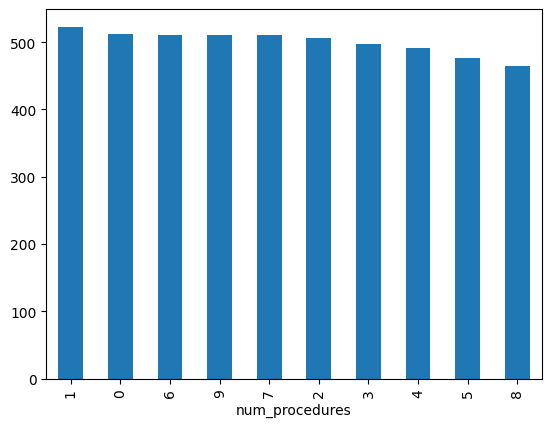

In [9]:
df['num_procedures'].value_counts().plot(kind='bar')

[]

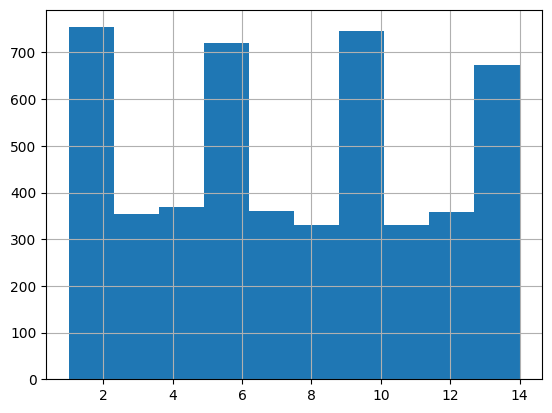

In [10]:
df['days_in_hospital'].hist().plot()

<Axes: xlabel='comorbidity_score'>

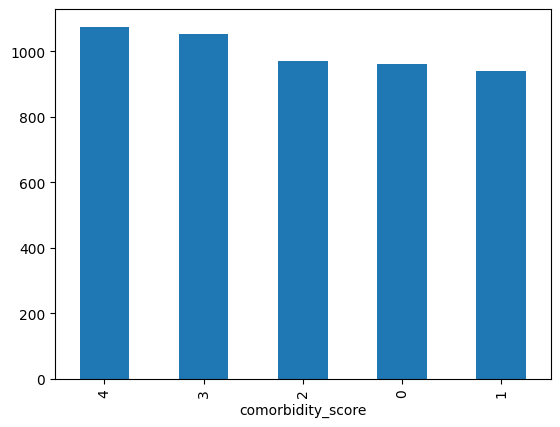

In [11]:
df['comorbidity_score'].value_counts().plot(kind='bar')

<Axes: xlabel='discharge_to'>

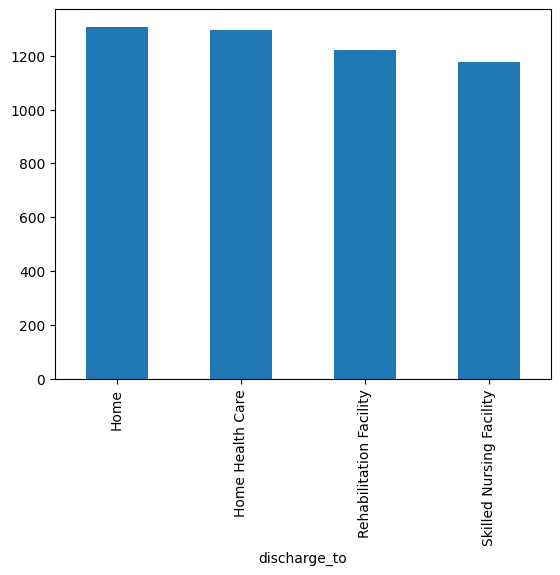

In [12]:
df['discharge_to'].value_counts().plot(kind='bar')

In [13]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['gender', 'primary_diagnosis', 'discharge_to']

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

ohe_data = ohe.fit_transform(df[categorical_cols])

ohe_df = pd.DataFrame(ohe_data, columns=ohe.get_feature_names_out(categorical_cols), index=df.index)

df_encoded = df.drop(columns=categorical_cols)

df_encoded = pd.concat([df_encoded, ohe_df], axis=1)

print("DataFrame after one-hot encoding:")
df_encoded.head()

DataFrame after one-hot encoding:


,age,num_procedures,days_in_hospital,comorbidity_score,readmitted,gender_Female,gender_Male,primary_diagnosis_COPD,primary_diagnosis_Diabetes,primary_diagnosis_Heart Disease,primary_diagnosis_Hypertension,primary_diagnosis_Kidney Disease,discharge_to_Home,discharge_to_Home Health Care,discharge_to_Rehabilitation Facility,discharge_to_Skilled Nursing Facility
0,69,1,2,1,0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,32,2,13,2,0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,89,1,7,1,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,78,9,2,2,0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,38,6,4,4,0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [14]:
binary_cols = [col for col in df_encoded.columns if any(cat in col for cat in categorical_cols)]

df_encoded[binary_cols] = df_encoded[binary_cols].astype(int)

df_encoded.head()

,age,num_procedures,days_in_hospital,comorbidity_score,readmitted,gender_Female,gender_Male,primary_diagnosis_COPD,primary_diagnosis_Diabetes,primary_diagnosis_Heart Disease,primary_diagnosis_Hypertension,primary_diagnosis_Kidney Disease,discharge_to_Home,discharge_to_Home Health Care,discharge_to_Rehabilitation Facility,discharge_to_Skilled Nursing Facility
0,69,1,2,1,0,0,1,0,0,1,0,0,0,1,0,0
1,32,2,13,2,0,1,0,1,0,0,0,0,0,0,1,0
2,89,1,7,1,0,0,1,0,1,0,0,0,1,0,0,0
3,78,9,2,2,0,0,1,1,0,0,0,0,0,0,0,1
4,38,6,4,4,0,0,1,0,1,0,0,0,0,0,1,0


In [15]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['readmitted'])
y = df_encoded['readmitted']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (4000, 15)
Testing set shape: (1000, 15)


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numeric_cols = ['age', 'num_procedures', 'days_in_hospital', 'comorbidity_score']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

model = LogisticRegression(penalty='l2', C=1.0, solver='liblinear', random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42, solver='liblinear')

Logistic Regression ROC-AUC Score: 0.5069

Classification Report:
              precision    recall  f1-score   support

           0       0.81      1.00      0.90       812
           1       0.00      0.00      0.00       188

    accuracy                           0.81      1000
   macro avg       0.41      0.50      0.45      1000
weighted avg       0.66      0.81      0.73      1000



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


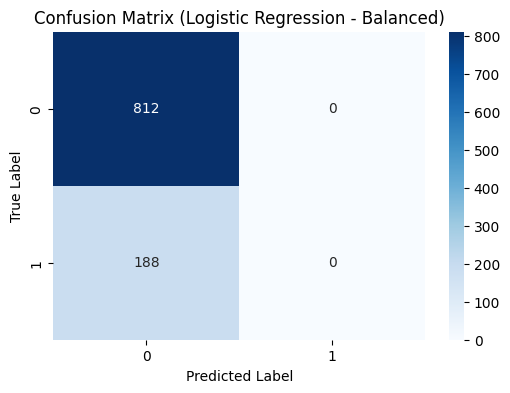

In [17]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC-AUC
auc_score = roc_auc_score(y_test, y_prob)
print(f"Logistic Regression ROC-AUC Score: {auc_score:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Logistic Regression - Balanced)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

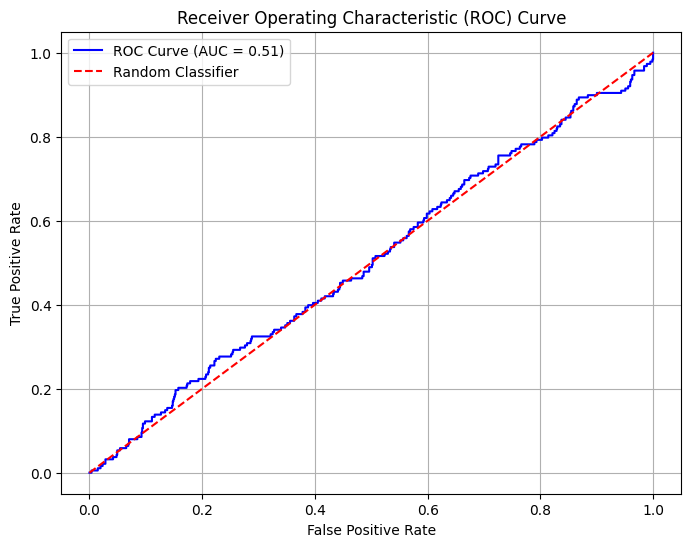

In [18]:
from sklearn.metrics import roc_curve

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()